<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/k_brazos/juntar_graficas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook para juntar gráficas

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/14

In [7]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git

fatal: destination path 'FernandezMartinezPolo-EML-RL' already exists and is not an empty directory.


In [8]:
!cd FernandezMartinezPolo-EML-RL/

In [9]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/FernandezMartinezPolo-EML-RL/k_brazos/src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecay, UCB1, UCB2, Softmax
from arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/FernandezMartinezPolo-EML-RL/k_brazos/src', '/content/FernandezMartinezPolo-EML-RL/k_brazos/src']


# Unión de resultados para plots conjuntos (k-bandidos)

Ahora vamos a generar algunas gráficas conjuntas de los tres algoritmos con la distribución normal, para poder mostrar la comparación más fácilmente tanto en el informe escrito como en la presentación. Tomamos para la comparación la mejor opción de cada algoritmo, que fueron:

- EpsilonDecay (epsilon=0.5, epsilon_min=0, lambda=0.001, tipo=lin)
- Softmax (tau=0.5)
- UCB1 (c=1.0)

In [10]:
import numpy as np


try:
    # Load the content of "datos_experimento1.npz"
    data_exp1 = np.load('/content/FernandezMartinezPolo-EML-RL/k_brazos/data/egreedy_normal_data.npz')

    # Load the content of "datos_experimento2.npz"
    data_exp2 = np.load('/content/FernandezMartinezPolo-EML-RL/k_brazos/data/softmax_normal_data.npz')

    # Load the content of "datos_experimento3.npz"
    data_exp3 = np.load('/content/FernandezMartinezPolo-EML-RL/k_brazos/data/ucb_normal_data.npz')

except FileNotFoundError as e:
    print(f"Error loading NPZ file: {e}. Please ensure the files are in the correct directory.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [13]:
egreedy_rewards_exp3 = data_exp1['rewards'][3]
softmax_rewards_exp3 = data_exp2['rewards'][2]
ucb_rewards_exp3 = data_exp3['rewards'][1]

egreedy_regrets_exp3 = data_exp1['regrets'][3]
softmax_regrets_exp3 = data_exp2['regrets'][2]
ucb_regrets_exp3 = data_exp3['regrets'][1]

egreedy_optimal_selections_exp3 = data_exp1['optimal_selections'][3]
softmax_optimal_selections_exp3 = data_exp2['optimal_selections'][2]
ucb_optimal_selections_exp3 = data_exp3['optimal_selections'][1]

print("Extracted data for the third experiment from all NPZ files.")

Extracted data for the third experiment from all NPZ files.


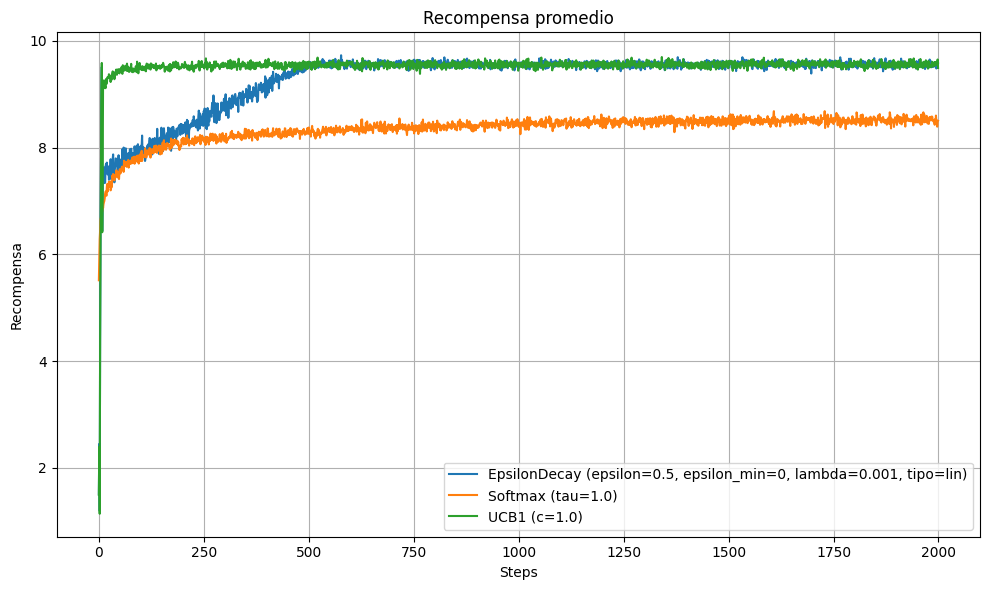

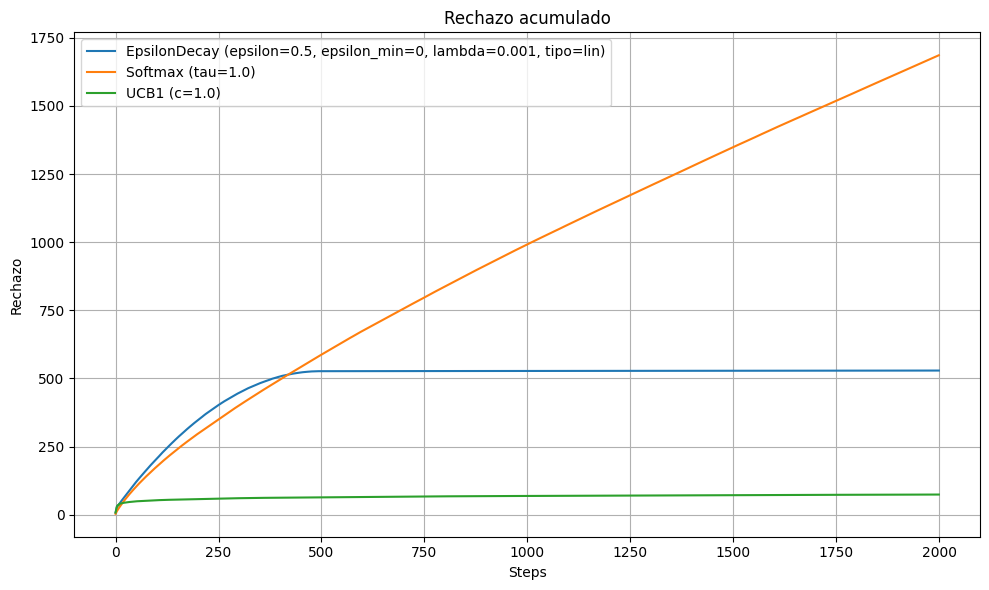

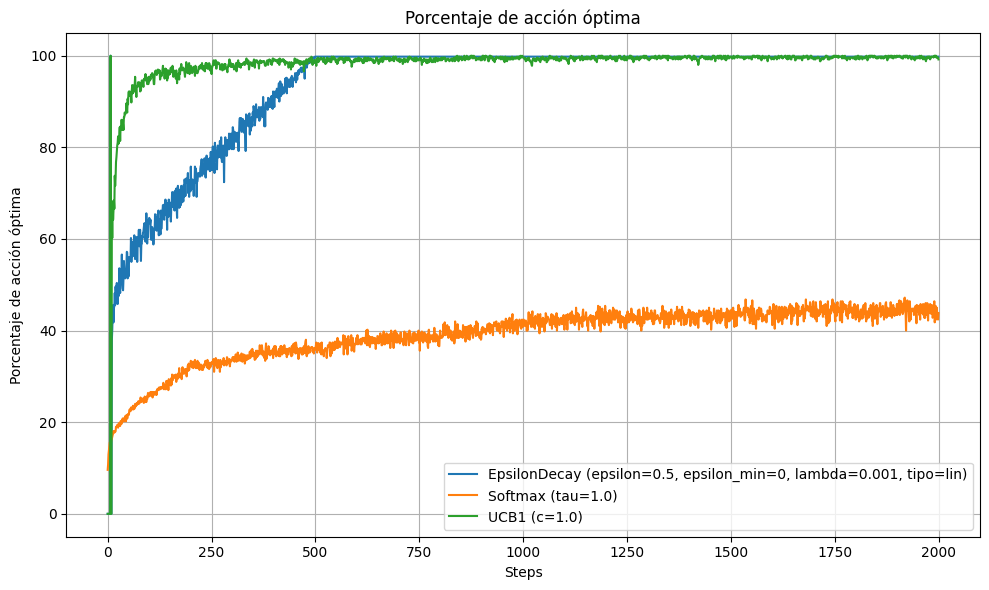

In [14]:
import matplotlib.pyplot as plt

# Plot Rewards
fig_rewards, ax_rewards = plt.subplots(figsize=(10, 6))
ax_rewards.plot(egreedy_rewards_exp3, label='EpsilonDecay (epsilon=0.5, epsilon_min=0, lambda=0.001, tipo=lin)')
ax_rewards.plot(softmax_rewards_exp3, label='Softmax (tau=1.0)')
ax_rewards.plot(ucb_rewards_exp3, label='UCB1 (c=1.0)')
ax_rewards.set_title('Recompensa promedio')
ax_rewards.set_xlabel('Steps')
ax_rewards.set_ylabel('Recompensa')
ax_rewards.legend()
ax_rewards.grid(True)
plt.tight_layout()
plt.savefig('rewards_comparison.png')
plt.show()

# Plot Regrets
fig_regrets, ax_regrets = plt.subplots(figsize=(10, 6))
ax_regrets.plot(egreedy_regrets_exp3, label='EpsilonDecay (epsilon=0.5, epsilon_min=0, lambda=0.001, tipo=lin)')
ax_regrets.plot(softmax_regrets_exp3, label='Softmax (tau=1.0)')
ax_regrets.plot(ucb_regrets_exp3, label='UCB1 (c=1.0)')
ax_regrets.set_title('Rechazo acumulado')
ax_regrets.set_xlabel('Steps')
ax_regrets.set_ylabel('Rechazo')
ax_regrets.legend()
ax_regrets.grid(True)
plt.tight_layout()
plt.savefig('regrets_comparison.png')
plt.show()

# Plot Optimal Selections
fig_optimal, ax_optimal = plt.subplots(figsize=(10, 6))
ax_optimal.plot(egreedy_optimal_selections_exp3, label='EpsilonDecay (epsilon=0.5, epsilon_min=0, lambda=0.001, tipo=lin)')
ax_optimal.plot(softmax_optimal_selections_exp3, label='Softmax (tau=1.0)')
ax_optimal.plot(ucb_optimal_selections_exp3, label='UCB1 (c=1.0)')
ax_optimal.set_title('Porcentaje de acción óptima')
ax_optimal.set_xlabel('Steps')
ax_optimal.set_ylabel('Porcentaje de acción óptima')
ax_optimal.legend()
ax_optimal.grid(True)
plt.tight_layout()
plt.savefig('optimal_selections_comparison.png')
plt.show()